---
title: "Sequences"
mathjax: true
toc: true
toc_sticky: true
categories: [data science, statistics]
---

This is the first in a series of posts about transformers.

Planning / ToC:
- data
- tokenization
- setting up tensors
- datasplits, batching
- sequences
- simple baseline model (bigram)


- running in scripts
- attention
- basic pytorch commands?
- what are we predicting?

In [1]:
import torch
import seaborn as sns
from smart_open import open

In [2]:
sns.set_context("talk")
sns.set_palette("colorblind")
cb_palette = sns.color_palette()

# The Shakespeare dataset

Why this as a teaching example? Common, open-source, intuitive for someone to understand

Real world dataset: The internet

In [3]:
# Inspect this link directly in the browser to see the data:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = open(DATA_URL, "r").read()

# See the first 300 characters of the data:
print(text[0:300])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


# Character level tokenization

Why this as a teaching example? Simple, limited vocabulary

Real world: tokenizers like ...  yields very high vocabulary (xx number of tokens)

From this corpus, we're able to derive a very simple vocabulary. Note that I'm showing the list of `chars` here so you can see special characters like newlines and spaces are part of the vocabulary.

In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)


print(f"{vocab_size}\nunique characters: {chars}")

65
unique characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


# Tensor setup

## Why tensors? Why not strings, numpy matrices, etc.


In [5]:
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}


def encode(s):
    """Take a string, output a list of integers."""
    return [stoi[c] for c in s]


def decode(l):
    """Take a list of integers, output a string."""
    return "".join([itos[i] for i in l])


print(encode("hii there"))
print(decode(encode("hii there")))

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


Modern tokenizers include Google SentencePiece, OpenAI tiktoken.

 Now tokenize the entire dataset. Why are we wrapping our tokens into a `torch.tensor` object? Practically, it plays nice with numpy or pandas, it can be moved to a GPU easily (`x.to('cuda')`), makes backpropagation calculation easy.

 Note that specifying `dtype=torch.long` makes the data type integer. The pytorch default is `float32` so constraining to integer is good practice to save memory.

In [6]:
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:200])

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59])


In [7]:
# Look again how the data looks as integers, and then decode it back to characters to sanity check
print(" ".join(map(str, data.tolist()))[0:100])
print(" ".join(decode(data.tolist()))[0:100])

18 47 56 57 58 1 15 47 58 47 64 43 52 10 0 14 43 44 53 56 43 1 61 43 1 54 56 53 41 43 43 42 1 39 52 


F i r s t   C i t i z e n : 
 B e f o r e   w e   p r o c e e d   a n y   f u r t h e r ,   h e a r 


## Data splits

In [8]:
# Split data into train and validation tensor objects
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

## Blocking and batching

### Blocking (or context length)

It's very computationally expensive to train the transformer by feeding it the whole text. Instead feed it chunks (or blocks) which is more computationally feasible.

In code, the maximum length of a chunk of data has to be specified. Here we'll call it `block_size` but it might be referred to as `context_length` in other documentation. 

In [9]:
block_size = 8

# We add a plus one so that we can have a target character for the last input character in the block
train_data[: block_size + 1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

When we sample like this, it actually has multiple examples packed into it since every character follows each other. In this set of 9 tokens, there are 8 training examples. During training, each token in this block will have its own set of tokens behind it as a training example. In this way, there are at least two benefits: (1) the training will be more efficient and (2) the model will get used to seeing examples of different sizes.

In [10]:
x = train_data[:block_size]
y = train_data[1 : block_size + 1]
for t in range(block_size):
    context = x[: t + 1]
    target = y[t]
    print(f"When input is {context} target is: {target}")

When input is tensor([18]) target is: 47
When input is tensor([18, 47]) target is: 56
When input is tensor([18, 47, 56]) target is: 57
When input is tensor([18, 47, 56, 57]) target is: 58
When input is tensor([18, 47, 56, 57, 58]) target is: 1
When input is tensor([18, 47, 56, 57, 58,  1]) target is: 15
When input is tensor([18, 47, 56, 57, 58,  1, 15]) target is: 47
When input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) target is: 58


What if your input size is longer than block size? In this simple architecture, you'd have to truncate the input.

### Batching

Batching is stacking up multiple blocks of data into a tensor that is capable of being fed into a GPU if available. This is done for efficiency and to keep the GPUs busy since a lot of parallel processing can happen without the data talking or interacting with each other.

The code below is generalizing the above loop for a batch of data.

In [11]:
# torch.manual_seed(1337)
torch.manual_seed(9999)
batch_size = 4  # how many independent sequences will we process in parallel?
block_size = 8  # what is the maximum context length for predictions?


def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == "train" else val_data
    # ix will return a tensor where values are randomly chosen between 
    # 0 and len(data) - block_size and the 
    # shape of the tensor will be (batch_size,)
    ix = torch.randint(len(data) - block_size, (batch_size,)) 

    # then it will get each block of training data 
    x = torch.stack([data[i : i + block_size] for i in ix])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    return x, y


xb, yb = get_batch("train")
print("inputs:")
print(xb.shape)
print(f"xb:\n {xb}")

print("targets:")
print(yb.shape)
print(f"yb:\n {yb}")

inputs:
torch.Size([4, 8])
xb:
 tensor([[ 1, 57, 47, 52, 57,  1, 51, 53],
        [43, 42, 43, 51, 54, 58, 47, 53],
        [53, 59,  1, 56, 59, 52,  1, 57],
        [56,  7, 57, 59, 47, 58, 43, 42]])
targets:
torch.Size([4, 8])
yb:
 tensor([[57, 47, 52, 57,  1, 51, 53, 57],
        [42, 43, 51, 54, 58, 47, 53, 52],
        [59,  1, 56, 59, 52,  1, 57, 53],
        [ 7, 57, 59, 47, 58, 43, 42,  1]])


In [12]:
len(train_data) - block_size

1003846

In [13]:
torch.randint(len(data) - block_size, (batch_size,)) 

tensor([162309, 283811, 193658, 667105])

In [14]:
for b in range(batch_size):  # batch dimension
    for t in range(block_size):  # time dimension
        context = xb[b, :t + 1]
        target = yb[b, t]

        print(f"When input is {context.tolist()} the target is: {target}")

When input is [1] the target is: 57
When input is [1, 57] the target is: 47
When input is [1, 57, 47] the target is: 52
When input is [1, 57, 47, 52] the target is: 57
When input is [1, 57, 47, 52, 57] the target is: 1
When input is [1, 57, 47, 52, 57, 1] the target is: 51
When input is [1, 57, 47, 52, 57, 1, 51] the target is: 53
When input is [1, 57, 47, 52, 57, 1, 51, 53] the target is: 57
When input is [43] the target is: 42
When input is [43, 42] the target is: 43
When input is [43, 42, 43] the target is: 51
When input is [43, 42, 43, 51] the target is: 54
When input is [43, 42, 43, 51, 54] the target is: 58
When input is [43, 42, 43, 51, 54, 58] the target is: 47
When input is [43, 42, 43, 51, 54, 58, 47] the target is: 53
When input is [43, 42, 43, 51, 54, 58, 47, 53] the target is: 52
When input is [53] the target is: 59
When input is [53, 59] the target is: 1
When input is [53, 59, 1] the target is: 56
When input is [53, 59, 1, 56] the target is: 59
When input is [53, 59, 1, 5

Now feed these into a transformer.

# Bigram Language Model

See [his video](https://www.youtube.com/watch?v=PaCmpygFfXo) more details.

Why this as a teaching example? Literally use only current (one) character to predict the next (and only one) character.

Real world: tokenizers like ...  yields very high vocabulary (xx number of tokens)

Before going into the model, let's explain some pytorch functions. Let's start with `nn.Embedding`. We'll initialize it with two parameters, each will be `vocab_size`. The first one represents the input, since we need a row for each input token. The second `vocab_size` represents the output, which is every possible next token. The values of the embedding table itself start off as random but then will be learned during back propagation.

In [176]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

What does `nn.Embedding` give us? Here, we're inspecting the values. (The first set of random numbers set by the random seed are consumed here. It will change if you re-run the cell.)

In [177]:
# .detach removes gradient tracking, .cpu moves the tensor to CPU memory, .numpy converts into numpy array
nn.Embedding(vocab_size, vocab_size).weight.detach().cpu().numpy()

array([[ 0.18077157, -0.06998809, -0.3596235 , ...,  1.6097364 ,
        -0.40322772, -0.8344702 ],
       [ 0.5978008 , -0.05140588, -0.06455874, ..., -1.4649245 ,
        -2.0555017 ,  1.8274626 ],
       [ 1.3035277 , -0.450132  ,  1.3471215 , ...,  0.19098009,
        -0.34250784,  1.7955089 ],
       ...,
       [ 0.4221906 , -1.8110788 , -1.011825  , ...,  0.54622185,
         0.2787799 ,  0.7279968 ],
       [-0.8108565 ,  0.24097146, -0.11390407, ...,  1.4508699 ,
         0.18363355,  0.30638522],
       [-1.4322455 , -0.28099647, -2.2789013 , ..., -0.55506617,
         1.0665984 ,  0.5363513 ]], shape=(65, 65), dtype=float32)

In [ ]:
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets):
        # idx and targets are both (B, T) tensor of integers
        # for each idx, it is plucking out the idx-th row out of that embedding table
        
        # logits is shape (B,T,C) 
        logits = self.token_embedding_table(idx)

        # targets not created yet but it will be used later to compute the loss function

        return logits

Let's initialize the model to inspect the token embeddings resulting from our input and the output. We have to set the seed again to see the same random numbers as above.

In [160]:
# note I'm setting the seed here again to get the same random numbers as above
torch.manual_seed(1337)
m = BigramLanguageModel(vocab_size) # initialize the model


Then we'll pass in `xb` which we already defined above as our batch of training data. It will get processed through the forward function, which returns another embedding at *each* B and T.

In [162]:
out = m(xb, yb) # pass in the input and targets to the model, but targets not used yet
print(out.shape) # for each example (B) and time step (T), return an embedding (C) 

torch.Size([4, 8, 65])


Let's remind ourselves what is going on. We're providing an input `xb` where each value represents a token.

In [199]:
xb

tensor([[ 1, 57, 47, 52, 57,  1, 51, 53],
        [43, 42, 43, 51, 54, 58, 47, 53],
        [53, 59,  1, 56, 59, 52,  1, 57],
        [56,  7, 57, 59, 47, 58, 43, 42]])

Let's look at the first value of `xb` which is a `1`. We simply look at the token embedding table at the `1` indexed row.

In [ ]:
m.token_embedding_table.weight[1, :]

tensor([ 0.5978, -0.0514, -0.0646, -0.4970,  0.4658, -0.2573, -1.0673,  2.0089,
        -0.5370,  0.2228,  0.6971, -1.4267,  0.9059,  0.1446,  0.2280,  2.4900,
        -1.2237,  1.0107,  0.5560, -1.5935, -1.2706,  0.6903, -0.1961,  0.3449,
        -0.3419,  0.4759, -0.7663, -0.4190, -0.4370, -1.0012, -0.4094, -1.6669,
        -1.3651, -0.1655,  0.9623,  0.0315, -0.7419, -0.2978,  0.0172, -0.1772,
        -0.1334,  0.2940,  1.3850,  0.1209,  2.5418, -0.6405, -1.9740, -0.3296,
         0.0080,  0.9262, -1.8846,  0.1670,  0.4586, -1.7662,  0.5860,  1.7510,
         0.2807,  0.3110, -0.6538, -0.6576,  0.3184, -0.5496, -1.4649, -2.0555,
         1.8275], grad_fn=<SelectBackward0>)

Since the BigramLanguageModel is just getting the embedding of the next character, we'd expect the embedding of *that* character (in our `out` matrix) to be represented by the previous character at this point. 

In [208]:
out[0, 0, :] # first 0th example, first 0th time step, all vocab_size logits

tensor([ 0.5978, -0.0514, -0.0646, -0.4970,  0.4658, -0.2573, -1.0673,  2.0089,
        -0.5370,  0.2228,  0.6971, -1.4267,  0.9059,  0.1446,  0.2280,  2.4900,
        -1.2237,  1.0107,  0.5560, -1.5935, -1.2706,  0.6903, -0.1961,  0.3449,
        -0.3419,  0.4759, -0.7663, -0.4190, -0.4370, -1.0012, -0.4094, -1.6669,
        -1.3651, -0.1655,  0.9623,  0.0315, -0.7419, -0.2978,  0.0172, -0.1772,
        -0.1334,  0.2940,  1.3850,  0.1209,  2.5418, -0.6405, -1.9740, -0.3296,
         0.0080,  0.9262, -1.8846,  0.1670,  0.4586, -1.7662,  0.5860,  1.7510,
         0.2807,  0.3110, -0.6538, -0.6576,  0.3184, -0.5496, -1.4649, -2.0555,
         1.8275], grad_fn=<SelectBackward0>)

In [212]:
torch.all(m.token_embedding_table.weight[1] == out[0, 0, :])

tensor(True)

At the next time step for the first example of `xb`, the token represented by `57` has its own embedding and those values will appear in the `out` tensor of the following time step.

In [211]:
torch.all(m.token_embedding_table.weight[57] == out[0, 1, :])

tensor(True)

At this point, the probabilities of each token in the output are all relatively low which is what we'd expect since the model has had zero training. The probabilities at this point are just from random chance.

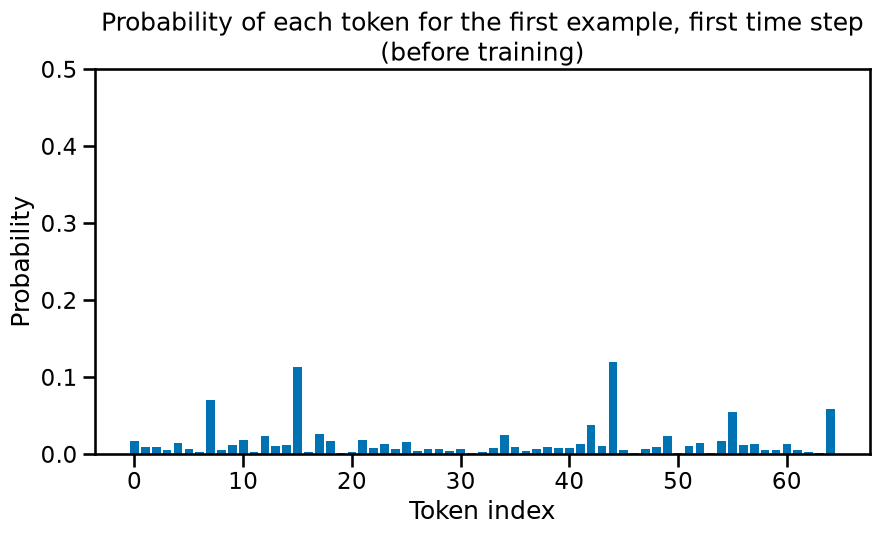

In [222]:
from scipy.special import softmax
from matplotlib import pyplot as plt


output_prob = softmax(out[0, 0, :].detach().cpu().numpy())
f, ax = plt.subplots(figsize=(10, 5))
ax.bar(x=range(len(output_prob)), height=output_prob)
ax.set(
    title="Probability of each token for the first example, first time step\n(before training)",
    ylim=(0, 0.5),
    xlabel="Token index",
    ylabel="Probability",
)
plt.show()

Let's move towards that by introducing the loss function.

# Cross-entropy as the loss function [SEPARATE POST]

Let's first look at how cross-entropy is calculated with `scipy` and with values in a simple numpy array before seeing how PyTorch expedites this calculation for us.

First, cross-entropy is a comparison of two probability distributions ($p$ and $q$), where $p$ serves as the target distribution and $q$ is the model's distribution at any point in training. The target distribution is what we hope the model will learn. Technically, cross-entropy can be applied to any probability distribution but in most machine learning instances, the probability distribution of the target is a 1 for correct class and 0 for all other classes.

 The mathematical formula for cross-entropy is:

$ H(p,q) = - \sum_{i=1}^{n} p(x_i) \log q(x_i)$

The first value of $p$ will be the reference for the first value of $q$, the second value of $p$ will be reference for second value of $q$, etc. Let's see this equation play out in a dummy example. Imagine that there are two multiple choice questions, each has three choices (a, b, or c). There is only one right answer for each question. A model has already determined logits for both questions.

In [76]:
import numpy as np
from scipy.special import softmax
from scipy.stats import entropy

logits_example = np.array([
    [1.5, 0.2, 3.1], # index 2 (or choice c) is highest at 3.1
    [2.0, 0.5, 0.1] # index 0 (or choice a) is highest at 2.0
    ])


However, as mentioned above in the cross-entropy formula, we don't use logits directly. We get probabilities from logits using softmax. In the `scipy` function, the softmax function allows us to get probabilities where each row (each multiple choice question) will sum to 1.

In [88]:
# need axis since each example is independent
prob_from_logits_example = softmax(logits_example, axis=1)
prob_from_logits_example

array([[0.16062801, 0.04377624, 0.79559575],
       [0.72849194, 0.16254852, 0.10895953]])

We now have two examples of probability distributions $q$ that we want to assess. Now we need our target distributions $p$ for each. The correct answers are represented in a different array.  The correct answer for the first question is 'c' (index 2) while it is 'b' for the second question (index 1). We then assign a `1` at the index for the correct answers and 0 in the other two positions.

In [89]:
prob_from_targets_example = np.array([
        [0, 0, 1],
        [0, 1, 0]
    ])

Let's translate the above mathematical formula into code, using the first example in a loop.

In [90]:
# Extract the single example vectors first
p_vector = prob_from_targets_example[0]
q_vector = prob_from_logits_example[0]

cross_entropy = 0
for p, q in zip(p_vector, q_vector):
    cross_entropy += p * np.log(q)

# Apply the negative sign at the end to get the final cross-entropy loss
cross_entropy = -cross_entropy
print(f"Cross-entropy loss for the first example (manually calculated): {cross_entropy}")

Cross-entropy loss for the first example (manually calculated): 0.22866407558146834


Let's see what we get when we use the `entropy` function from `scipy` to calculate cross-entropy.

In [91]:
cross_entropy_scipy = entropy(pk=prob_from_targets_example, axis=1) + entropy(pk=prob_from_targets_example, qk=prob_from_logits_example, axis=1) # This line is getting both examples
print(f"Cross-entropy loss for the first example (using scipy function): {cross_entropy_scipy[0]}")


Cross-entropy loss for the first example (using scipy function): 0.22866407558146834


Now let's look at how PyTorch makes this calculation much easier for us. First, we need to make our numpy array a tensor.

In [92]:
logits_example_tensor = torch.from_numpy(logits_example)
logits_example_tensor

tensor([[1.5000, 0.2000, 3.1000],
        [2.0000, 0.5000, 0.1000]], dtype=torch.float64)

Then, we need to make our target array but here, only the *index* of the correct answer is needed. PyTorch one-hot encodes to a probability distribution underneath the hood for us.

In [93]:
targets_example = torch.tensor([2, 1])  # meaning: correct answer is 'c', then correct answer is 'b'
targets_example

tensor([2, 1])

Now, we can use PyTorch from the `torch.nn.functional` module to compute cross-entropy. One point to be aware of: the PyTorch function averages across each row by default yielding a single scalar value. To get the cross-entropy for each row, add `reduction='none'`.

In [97]:
F.cross_entropy(torch.from_numpy(logits_example), targets_example, reduction='none')

tensor([0.2287, 1.8168], dtype=torch.float64)

In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Tue, 16 Jun 2026

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.14.1

seaborn   : 0.13.2
smart_open: 7.6.1
torch     : 2.12.0

Watermark: 2.6.0

